# Notebook 2: EDA & Word Cloud
**Project: Analisis Komentar YouTube #PESTABABI**

Tujuan notebook ini:
1. Analisis video & channel terpopuler
2. Tren waktu komentar (time series)
3. Distribusi interaksi (likes)
4. Text preprocessing (case folding, regex, stopword removal, stemming)
5. Word Cloud: umum, by likes kategori, by channel type

## 1. Import Libraries

In [1]:
%pip install plotly wordcloud sastrawi
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud, STOPWORDS
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLTK untuk stopwords Bahasa Indonesia
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Sastrawi untuk stemming Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Data Bersih

In [3]:
df = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'pestababi_clean.csv'),
    parse_dates=['Tanggal_Rilis']
)

print(f'Shape: {df.shape}')
display(df.head(3))
print('\nTipe data:')
print(df.dtypes)

Shape: (10763, 9)


,Video_ID,Komentar,Jumlah_Suka,Judul_Video,Channel,Tanggal_Rilis,Panjang_Komentar,Jumlah_Kata,Kategori_Likes
0,Kjq6YuxPWuw,"Tolong dihapus videonya, ini pelanggaran Hak C...",7,Pesta babi (Official trailer full movie),Gilberth official,2026-05-17 18:37:03+00:00,115,17,medium
1,Kjq6YuxPWuw,😢😢😢,1,Pesta babi (Official trailer full movie),Gilberth official,2026-05-17 18:37:03+00:00,3,1,low
2,Kjq6YuxPWuw,Begitu kejam nya pemerintah terhadap rakyatnya...,1,Pesta babi (Official trailer full movie),Gilberth official,2026-05-17 18:37:03+00:00,58,7,low



Tipe data:
Video_ID                            str
Komentar                            str
Jumlah_Suka                       int64
Judul_Video                         str
Channel                             str
Tanggal_Rilis       datetime64[us, UTC]
Panjang_Komentar                  int64
Jumlah_Kata                       int64
Kategori_Likes                      str
dtype: object


---
# BAGIAN A: EXPLORATORY DATA ANALYSIS
---

## 3. Analisis Video & Channel Terpopuler

=== Top 10 Video berdasarkan Jumlah Komentar ===


,Judul_Video,Channel,Jumlah_Komentar,Total_Likes,Rata_Likes
15,PESTA BABI (Official Trailer),Indonesia Baru,5363,30057,5.604512
13,PESTA BABI,Pari Kesit,1802,7095,3.937292
21,Represi dalam Pemutaran Film Pesta Babi | Boco...,Tempodotco,732,4188,5.721311
22,Terbongkar Pendana Film Pesta Babi 🙀,Kucing Mujair,721,3111,4.314840
17,"PESTA BABI, FILM YANG HARUS DITONTON SEKALI SE...",Nas Creativy,573,921,1.607330
6,"GEGERR💥FILM “PESTA BABI” LAGI RAMAI, ADA PERAN...",YudaMedia HD,353,721,2.042493
16,PESTA BABI MENGERIKAN? SAAT BEBERAPA OKNUM TNI...,GEMBULIKUM,301,686,2.279070
19,Pesta Babi (Official Music Video) 📢🎶,rumahcase music,195,800,4.102564
1,Aparat Panik! Ada Apa di Balik Dokumenter &#39...,Daftar Populer,133,138,1.037594
18,Pemerintah Bantah Kerahkan Aparat Bubarkan Fil...,Warta Kota Production,77,52,0.675325


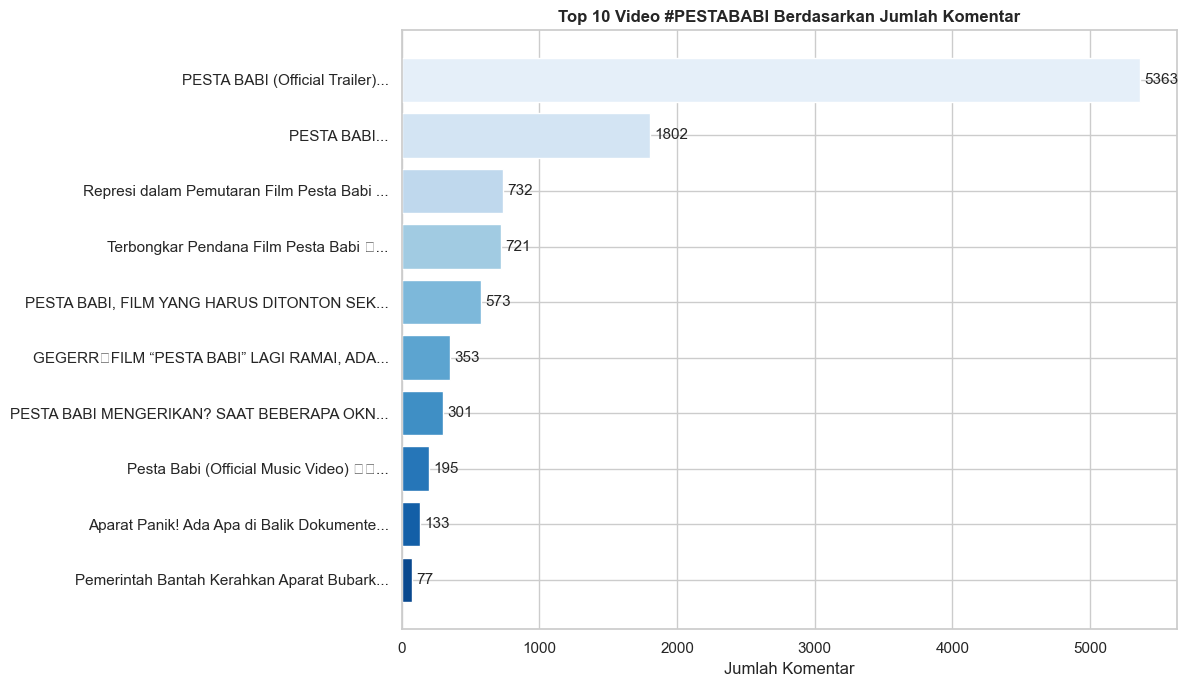

In [4]:
# --- Jumlah komentar per video ---
komentar_per_video = (
    df.groupby(['Judul_Video', 'Channel'])
    .agg(
        Jumlah_Komentar=('Komentar', 'count'),
        Total_Likes=('Jumlah_Suka', 'sum'),
        Rata_Likes=('Jumlah_Suka', 'mean')
    )
    .reset_index()
    .sort_values('Jumlah_Komentar', ascending=False)
)

print('=== Top 10 Video berdasarkan Jumlah Komentar ===')
display(komentar_per_video.head(10))

# Plot horizontal bar
top10 = komentar_per_video.head(10).iloc[::-1]  # balik urutan untuk horizontal bar

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top10['Judul_Video'].str[:40] + '...', top10['Jumlah_Komentar'],
                color=sns.color_palette('Blues_r', len(top10)))
ax.bar_label(bars, padding=3, fmt='%d')
ax.set_xlabel('Jumlah Komentar')
ax.set_title('Top 10 Video #PESTABABI Berdasarkan Jumlah Komentar', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'processed', 'plot_top_video.png'), dpi=150)
plt.show()

In [5]:
%pip install nbformat>=4.2.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# --- Interaksi per channel ---
komentar_per_channel = (
    df.groupby('Channel')
    .agg(
        Jumlah_Komentar=('Komentar', 'count'),
        Total_Likes=('Jumlah_Suka', 'sum')
    )
    .reset_index()
    .sort_values('Jumlah_Komentar', ascending=False)
)

fig = px.bar(
    komentar_per_channel,
    x='Channel', y='Jumlah_Komentar',
    color='Total_Likes',
    color_continuous_scale='Blues',
    title='Distribusi Komentar & Total Likes per Channel',
    labels={'Jumlah_Komentar': 'Jumlah Komentar', 'Total_Likes': 'Total Likes'},
    template='plotly_white'
)
fig.show()

## 4. Tren Waktu Komentar (Time Series)

> Kita plot berdasarkan **tanggal rilis video**, karena kolom `Tanggal_Rilis` berasal dari metadata video YouTube.
> Ini menunjukkan pada gelombang rilis video kapan diskusi publik paling ramai.

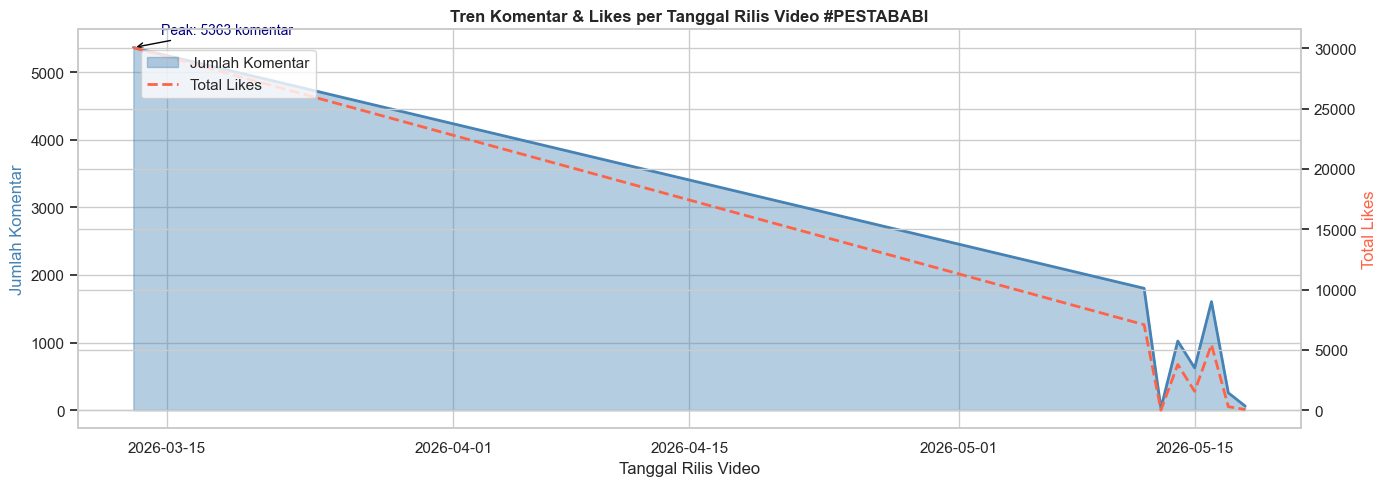

In [7]:
# Normalize timezone ke date saja
df['Tanggal'] = pd.to_datetime(df['Tanggal_Rilis']).dt.date

tren = df.groupby('Tanggal').agg(
    Jumlah_Komentar=('Komentar', 'count'),
    Total_Likes=('Jumlah_Suka', 'sum')
).reset_index()
tren['Tanggal'] = pd.to_datetime(tren['Tanggal'])
tren = tren.sort_values('Tanggal')

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(tren['Tanggal'], tren['Jumlah_Komentar'],
                alpha=0.4, color='steelblue', label='Jumlah Komentar')
ax1.plot(tren['Tanggal'], tren['Jumlah_Komentar'], color='steelblue', lw=2)
ax1.set_ylabel('Jumlah Komentar', color='steelblue')
ax1.set_xlabel('Tanggal Rilis Video')

ax2 = ax1.twinx()
ax2.plot(tren['Tanggal'], tren['Total_Likes'], color='tomato', lw=2, linestyle='--', label='Total Likes')
ax2.set_ylabel('Total Likes', color='tomato')

# Annotate spike tertinggi
max_idx = tren['Jumlah_Komentar'].idxmax()
max_row = tren.loc[max_idx]
ax1.annotate(
    f"Peak: {max_row['Jumlah_Komentar']} komentar",
    xy=(max_row['Tanggal'], max_row['Jumlah_Komentar']),
    xytext=(20, 10), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10, color='navy'
)

plt.title('Tren Komentar & Likes per Tanggal Rilis Video #PESTABABI', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'processed', 'plot_tren_waktu.png'), dpi=150)
plt.show()

## 5. Distribusi Interaksi (Jumlah Likes)

=== Statistik Deskriptif Jumlah_Suka ===
count    10763.000000
mean         4.492428
std         87.871104
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       5447.000000
Name: Jumlah_Suka, dtype: float64

Persentase komentar dengan 0 likes: 79.3%
Komentar dengan likes >= 10: 293 baris


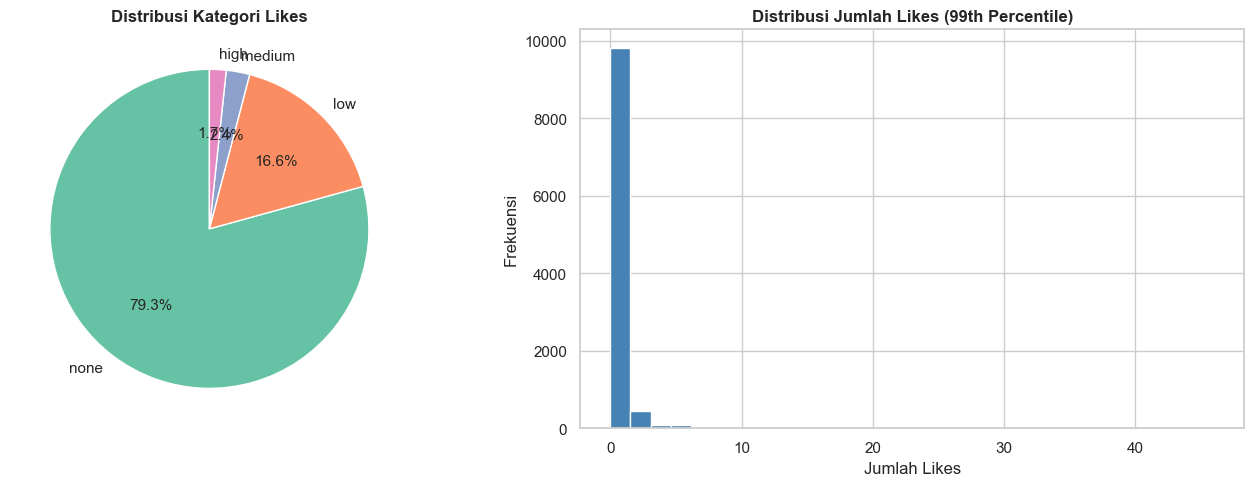

In [8]:
# Statistik deskriptif
print('=== Statistik Deskriptif Jumlah_Suka ===')
print(df['Jumlah_Suka'].describe())
print(f'\nPersentase komentar dengan 0 likes: {(df["Jumlah_Suka"]==0).mean()*100:.1f}%')
print(f'Komentar dengan likes >= 10: {(df["Jumlah_Suka"]>=10).sum()} baris')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart distribusi kategori
kategori_counts = df['Kategori_Likes'].value_counts()
axes[0].pie(
    kategori_counts,
    labels=kategori_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2'),
    startangle=90
)
axes[0].set_title('Distribusi Kategori Likes', fontweight='bold')

# Histogram (filter outlier untuk visual yang bersih)
df_filtered = df[df['Jumlah_Suka'] <= df['Jumlah_Suka'].quantile(0.99)]
axes[1].hist(df_filtered['Jumlah_Suka'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Likes (99th Percentile)', fontweight='bold')
axes[1].set_xlabel('Jumlah Likes')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'processed', 'plot_distribusi_likes.png'), dpi=150)
plt.show()

---
# BAGIAN B: TEXT PREPROCESSING & WORD CLOUD
---

## 6. Text Preprocessing Pipeline

In [9]:
# ============================
#  SETUP STOPWORDS & STEMMER
# ============================

# Stopwords Sastrawi (komprehensif untuk Bahasa Indonesia)
sastrawi_sw_factory = StopWordRemoverFactory()
sastrawi_stopwords = set(sastrawi_sw_factory.get_stop_words())

# Stopwords NLTK Indonesia
try:
    nltk_id_sw = set(stopwords.words('indonesian'))
except:
    nltk_id_sw = set()

# Custom stopwords tambahan: slang, singkatan umum, kata tidak bermakna
custom_stopwords = {
    'yg', 'dgn', 'aja', 'udh', 'udah', 'gak', 'ga', 'gakk', 'gak',
    'nya', 'kk', 'bang', 'bgt', 'banget', 'sih', 'deh', 'nih', 'nah',
    'lah', 'dong', 'kan', 'kah', 'tuh', 'teh', 'atuh', 'mah',
    'wkwk', 'wkwkwk', 'haha', 'hehe', 'hihi', 'huhu',
    'iya', 'iyaiya', 'ok', 'oke', 'oks', 'okelah',
    'emg', 'emang', 'memang', 'kayak', 'kaya', 'kyk',
    'https', 'http', 'www', 'com', 'co', 'id',
    'pesta', 'babi', 'pestababi'  # kata kunci utama, tidak informatif untuk WC
}

all_stopwords = sastrawi_stopwords | nltk_id_sw | custom_stopwords

# Stemmer Sastrawi
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

print(f'Total stopwords: {len(all_stopwords)}')
print('Stemmer siap ✅')

Total stopwords: 819
Stemmer siap ✅


In [10]:
def preprocess_text(text, use_stemming=False):
    """
    Pipeline preprocessing teks komentar Bahasa Indonesia.
    
    Langkah:
    1. Lowercase
    2. Hapus URL
    3. Hapus emoji & karakter non-ASCII
    4. Hapus tanda baca & angka
    5. Hapus spasi berlebih
    6. Tokenisasi & stopword removal
    7. (Opsional) Stemming
    """
    if not isinstance(text, str):
        return ''
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Hapus emoji & karakter non-latin (termasuk karakter Unicode emoji)
    text = re.sub(r'[^\x00-\x7F\u00C0-\u024F]+', ' ', text)
    
    # 4. Hapus tanda baca & angka
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 5. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 6. Tokenisasi & stopword removal
    tokens = [word for word in text.split() if word not in all_stopwords and len(word) > 2]
    
    # 7. Stemming (opsional — lambat, aktifkan seperlunya)
    if use_stemming:
        tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)


# Test preprocessing
sample = df['Komentar'].iloc[0]
print(f'Original : {sample}')
print(f'Processed: {preprocess_text(sample)}')

Original : Tolong dihapus videonya, ini pelanggaran Hak Cipta. Karena pihak Watchdoc belum keluarkan film ini akun resminya 🙏🏽
Processed: dihapus videonya pelanggaran hak cipta watchdoc keluarkan film akun resminya


In [11]:
# Terapkan ke seluruh dataset
# use_stemming=False dulu untuk kecepatan; set True jika mau hasil lebih proper
print('Memproses teks... (ini mungkin butuh beberapa menit)')
df['Komentar_Bersih'] = df['Komentar'].apply(lambda x: preprocess_text(x, use_stemming=False))

# Hapus baris dengan hasil preprocessing kosong
df = df[df['Komentar_Bersih'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f'Preprocessing selesai ✅ Total baris: {len(df)}')

# Simpan dataset dengan kolom teks bersih
df.to_csv(os.path.join(PROCESSED_DIR, 'pestababi_clean_preprocessed.csv'), 
        index=False, encoding='utf-8-sig')
print('File pestababi_clean_preprocessed.csv tersimpan ✅')

Memproses teks... (ini mungkin butuh beberapa menit)
Preprocessing selesai ✅ Total baris: 10536
File pestababi_clean_preprocessed.csv tersimpan ✅


## 7. Word Cloud

In [12]:
def generate_wordcloud(text_series, title, ax, colormap='Blues', bg_color='white'):
    """Helper function untuk membuat word cloud dari pandas Series."""
    combined_text = ' '.join(text_series.dropna().values)
    if not combined_text.strip():
        ax.text(0.5, 0.5, 'Data tidak cukup', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold')
        return
    
    wc = WordCloud(
        width=800, height=400,
        background_color=bg_color,
        colormap=colormap,
        max_words=100,
        min_font_size=10,
        collocations=False  # Hindari pasangan kata yang sama berulang
    ).generate(combined_text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

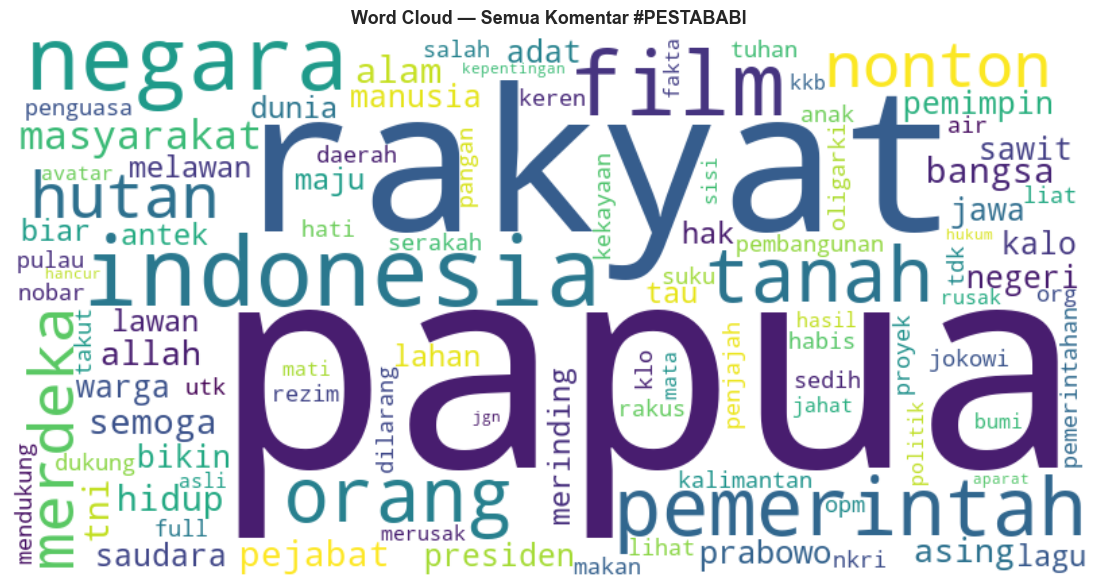

In [13]:
# =========================================
#  WORD CLOUD 1: Umum (semua komentar)
# =========================================
fig, ax = plt.subplots(figsize=(14, 6))
generate_wordcloud(df["Komentar_Bersih"], 'Word Cloud — Semua Komentar #PESTABABI', ax, colormap='viridis')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'wc_umum.png'), dpi=150, bbox_inches='tight')
plt.show()

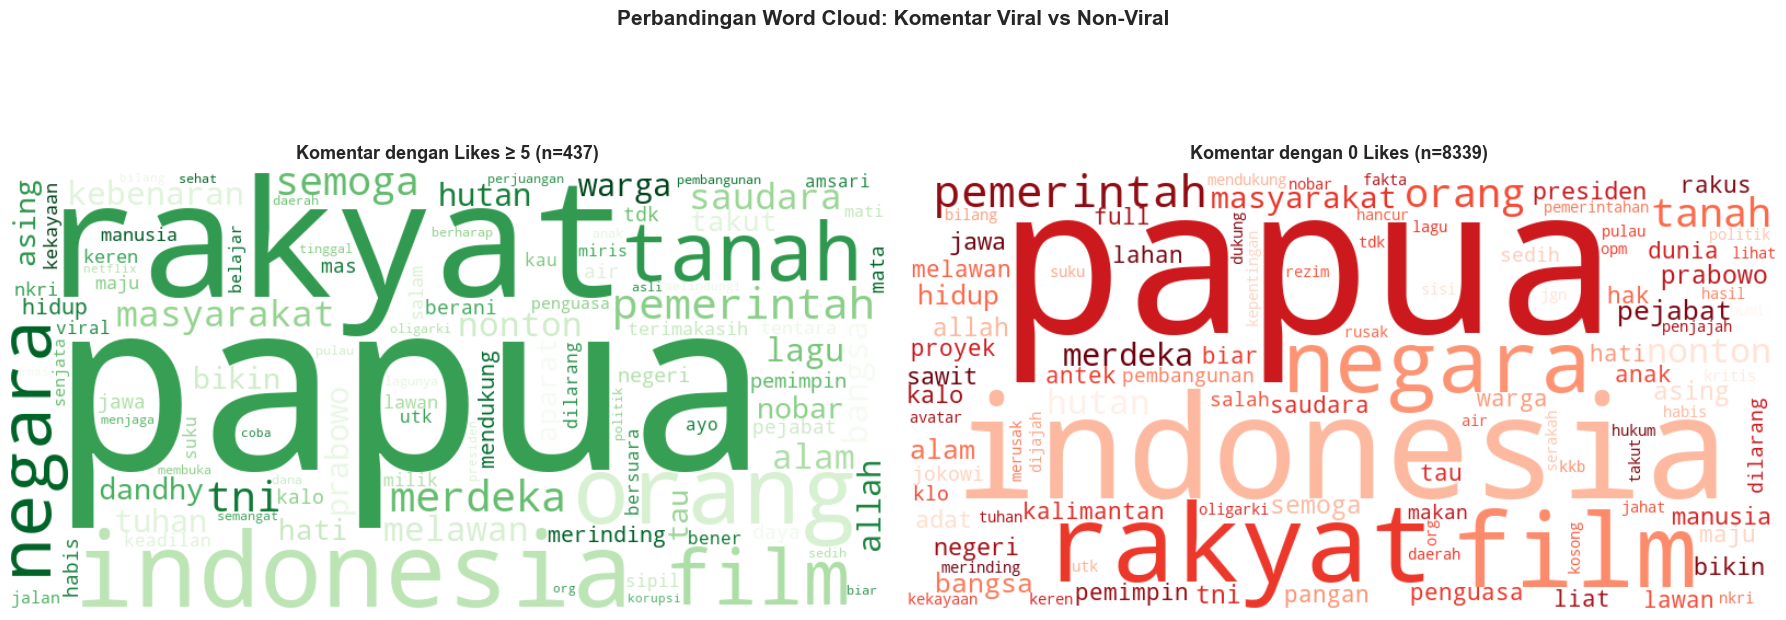

In [15]:
# =========================================================
#  WORD CLOUD 2: Perbandingan Likes Tinggi vs Likes Rendah
# =========================================================
df_high_likes = df[df['Jumlah_Suka'] >= 5]
df_low_likes  = df[df['Jumlah_Suka'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

generate_wordcloud(
    df_high_likes["Komentar_Bersih"],
    f'Komentar dengan Likes ≥ 5 (n={len(df_high_likes)})',
    axes[0], colormap='Greens'
)
generate_wordcloud(
    df_low_likes["Komentar_Bersih"],
    f'Komentar dengan 0 Likes (n={len(df_low_likes)})',
    axes[1], colormap='Reds'
)

fig.suptitle('Perbandingan Word Cloud: Komentar Viral vs Non-Viral', 
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'wc_likes_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

Distribusi tipe channel:
Tipe_Channel
independen     9525
media_resmi    1011
Name: count, dtype: int64


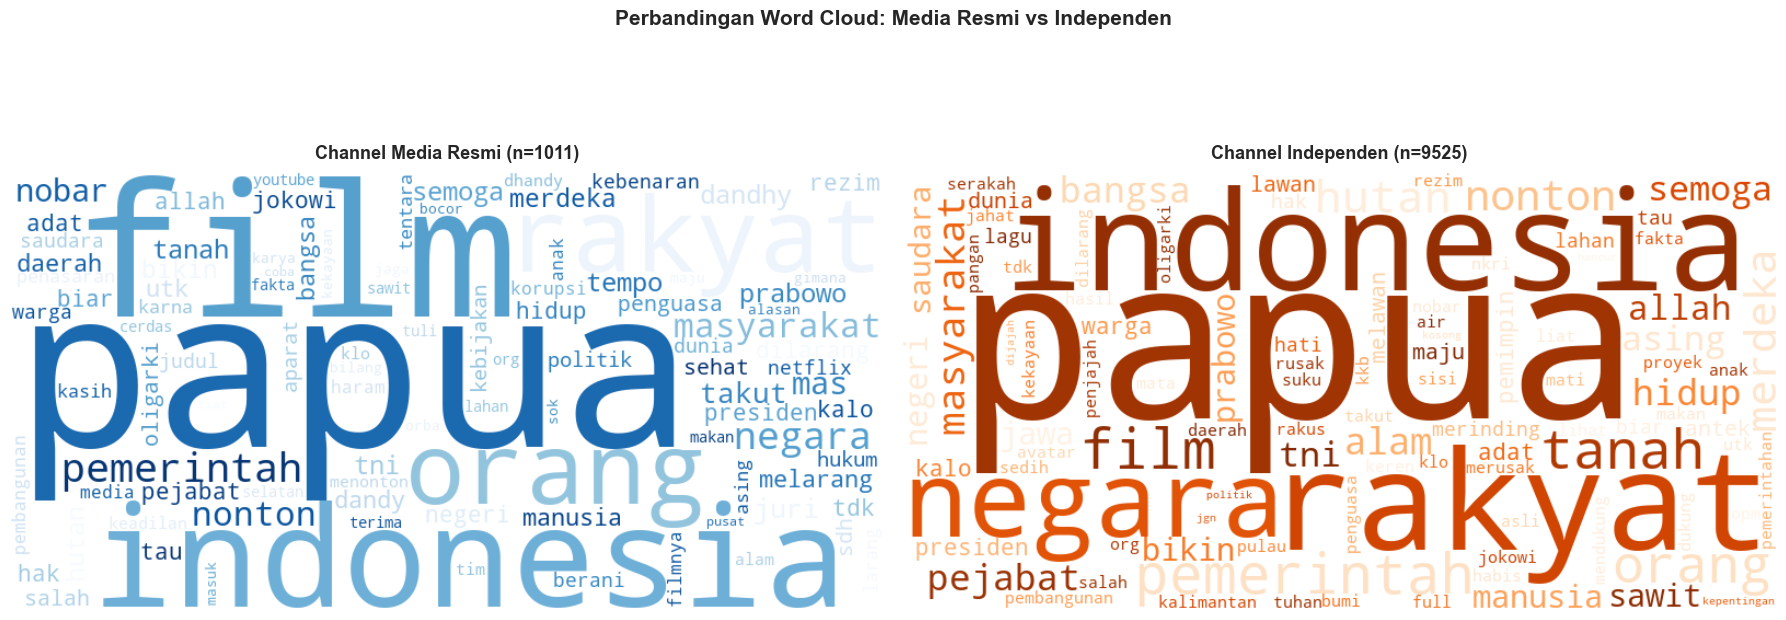

In [17]:
# =========================================================
#  WORD CLOUD 3: Perbandingan berdasarkan Channel
#  Klasifikasi manual: 'media_resmi' vs 'independen'
# =========================================================

# Daftar keyword channel media resmi (sesuaikan dengan data aktual)
media_resmi_keywords = ['kompas', 'tempo', 'tvone', 'metro', 'cnnindonesia', 
                        'detik', 'tribun', 'liputan6', 'antara', 'republika']

def klasifikasi_channel(channel_name):
    name_lower = str(channel_name).lower()
    for kw in media_resmi_keywords:
        if kw in name_lower:
            return 'media_resmi'
    return 'independen'

df['Tipe_Channel'] = df['Channel'].apply(klasifikasi_channel)

print('Distribusi tipe channel:')
print(df['Tipe_Channel'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (tipe, cmap) in enumerate([('media_resmi', 'Blues'), ('independen', 'Oranges')]):
    subset = df[df['Tipe_Channel'] == tipe]["Komentar_Bersih"]
    generate_wordcloud(
        subset,
        f'Channel {tipe.replace("_", " ").title()} (n={len(subset)})',
        axes[idx], colormap=cmap
    )

fig.suptitle('Perbandingan Word Cloud: Media Resmi vs Independen',
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'wc_channel_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Top 20 Kata Paling Sering Muncul (Frequency Chart)

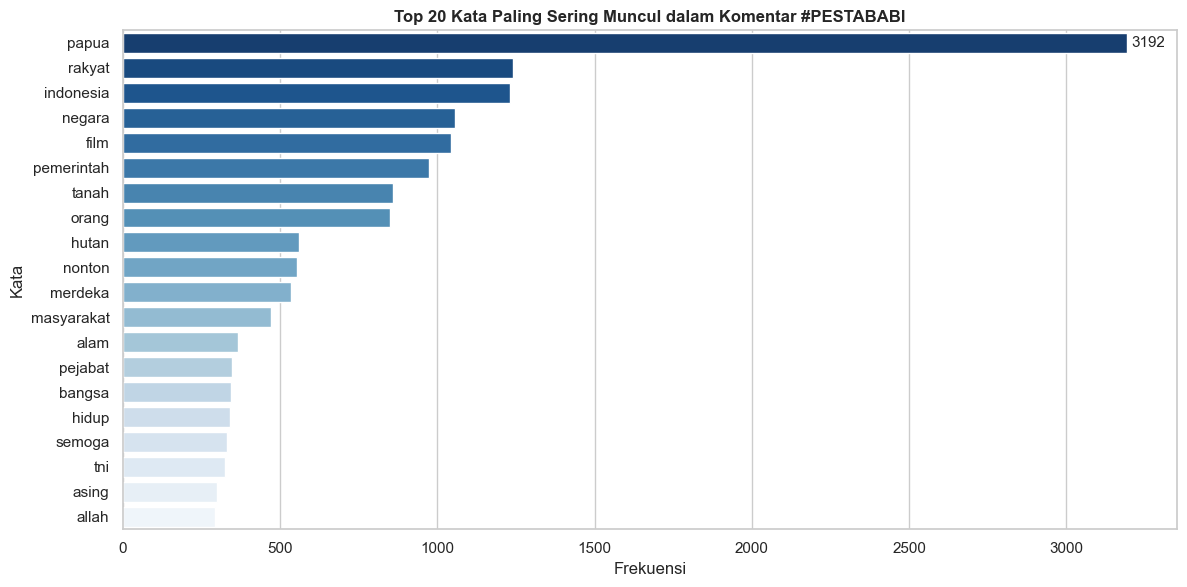

      Kata  Frekuensi
     papua       3192
    rakyat       1241
 indonesia       1232
    negara       1057
      film       1043
pemerintah        973
     tanah        858
     orang        850
     hutan        562
    nonton        553
   merdeka        535
masyarakat        472
      alam        366
   pejabat        347
    bangsa        344
     hidup        340
    semoga        332
       tni        326
     asing        299
     allah        294


In [18]:
from collections import Counter

all_words = ' '.join(df["Komentar_Bersih"].dropna()).split()
word_freq = Counter(all_words)
top20 = pd.DataFrame(word_freq.most_common(20), columns=['Kata', 'Frekuensi'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top20, x='Frekuensi', y='Kata', palette='Blues_r', ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set_title('Top 20 Kata Paling Sering Muncul dalam Komentar #PESTABABI', fontweight='bold')
ax.set_xlabel('Frekuensi')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'plot_top20_kata.png'), dpi=150)
plt.show()

print(top20.to_string(index=False))